In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv'
df = pd.read_csv(url)

print('Shape del dataset completo:', df.shape)
df.head()

Shape del dataset completo: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df = df[['Latitude', 'Longitude', 'MedInc']]

df.columns.tolist()

df.describe()

,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


In [3]:
df.isnull().sum()

Latitude     0
Longitude    0
MedInc       0
dtype: int64

In [4]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
X_train.shape
X_test.shape

(4128, 3)

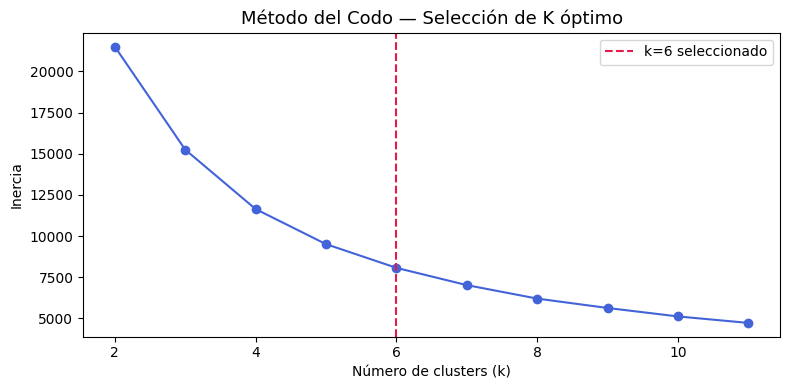

La curva confirma que k=6 es un buen punto de equilibrio entre inercia y complejidad.


In [ ]:
features = ['Latitude', 'Longitude', 'MedInc']

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled  = scaler.transform(X_test[features])

# Método del codo para confirmar k=6
inertias = []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, marker='o', color='#4363d8')
ax.axvline(x=6, color='#e6194b', linestyle='--', label='k=6 seleccionado')
ax.set_title('Método del Codo — Selección de K óptimo', fontsize=13)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.legend()
plt.tight_layout()
plt.show()

print('La curva confirma que k=6 es un buen punto de equilibrio entre inercia y complejidad.')

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)  

X_train = X_train.copy()
X_train['cluster'] = kmeans.labels_.astype(str)

print('Distribución de clusters en el conjunto de entrenamiento:')
print(X_train['cluster'].value_counts().sort_index())

Distribución de clusters en el conjunto de entrenamiento:
cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64


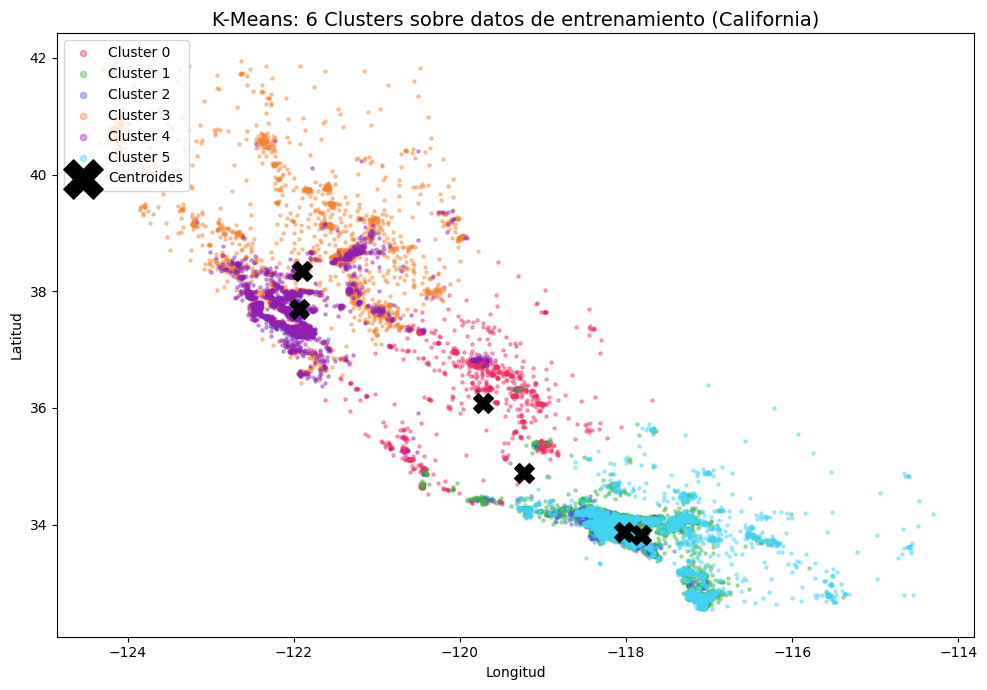

In [ ]:
colors = ["#f12e5f", '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4']


centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))

for i, cluster_id in enumerate(['0', '1', '2', '3', '4', '5']):
    subset = X_train[X_train['cluster'] == cluster_id]
    ax.scatter(
        subset['Longitude'], subset['Latitude'],
        c=colors[i], label=f'Cluster {cluster_id}',
        alpha=0.4, s=5
    )

ax.scatter(
    centroids_orig[:, 1], centroids_orig[:, 0],
    c='black', marker='X', s=200, zorder=5, label='Centroides'
)

ax.set_title('K-Means: 6 Clusters sobre datos de entrenamiento (California)', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(markerscale=2, loc='upper left')
plt.tight_layout()
plt.show()

Podemos observar 6 grupos bien diferenciados geográficamente sobre el mapa de California.
Los clusters reflejan zonas como el área de la Bahía de San Francisco, Los Ángeles, la costa central,
el interior del valle central y las regiones del norte y sur. El ingreso medio también influye en la
separación, lo que da lugar a agrupaciones que combinan ubicación geográfica con nivel socioeconómico.

Usamos el modelo K-Means ya entrenado para predecir a qué cluster pertenece cada vivienda del conjunto de prueba. Luego añadimos estos puntos al gráfico anterior para comprobar visualmente si las predicciones son coherentes con los clusters aprendidos.

In [8]:
X_test = X_test.copy()
X_test['cluster'] = kmeans.predict(X_test_scaled).astype(str)

print(X_test['cluster'].value_counts().sort_index())

cluster
0     337
1     829
2     112
3     962
4     514
5    1374
Name: count, dtype: int64


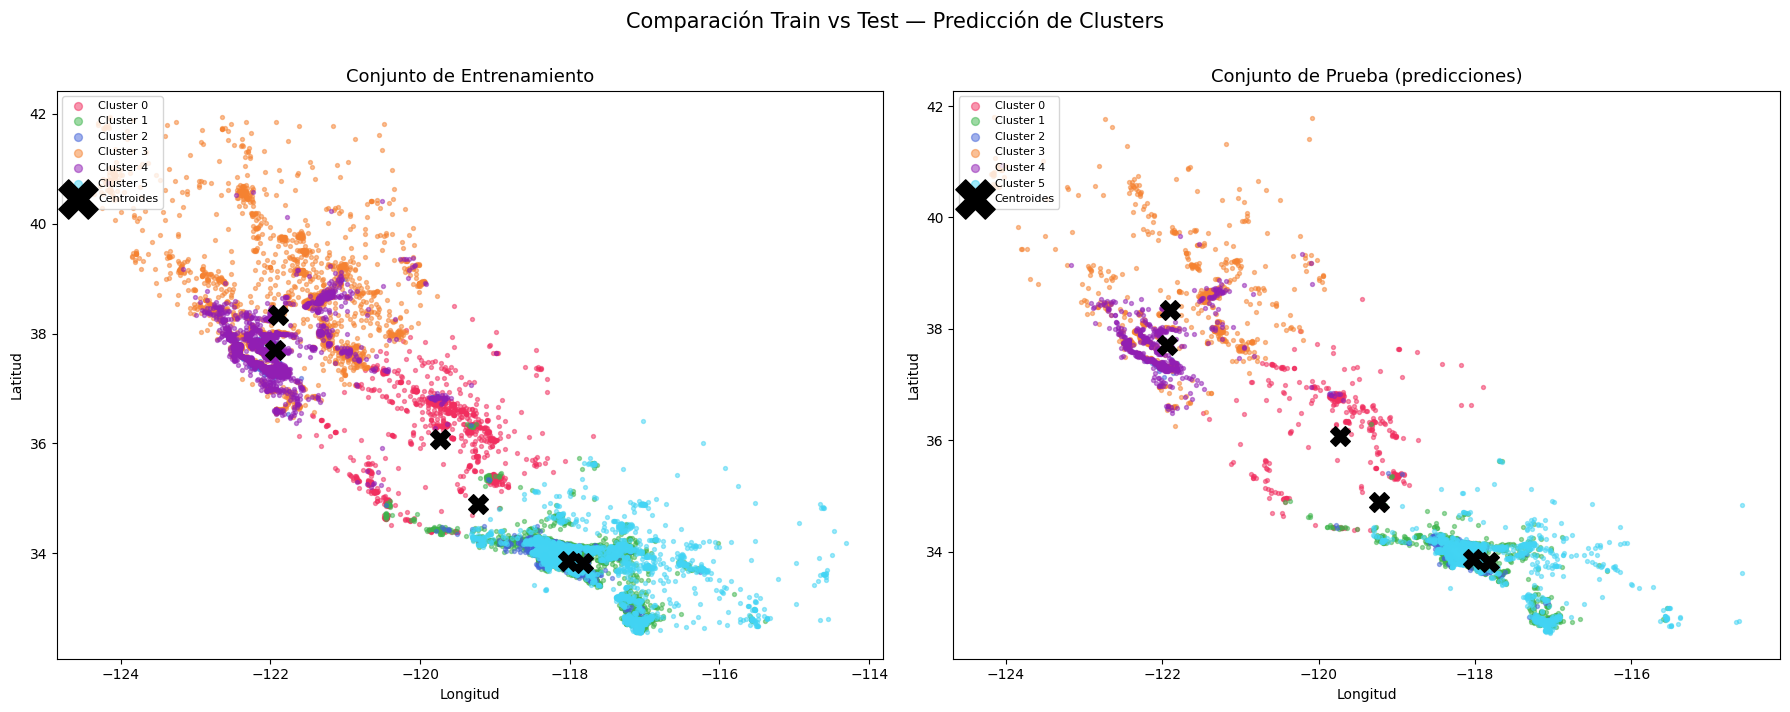

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (data, title) in zip(axes, [
    (X_train, 'Conjunto de Entrenamiento'),
    (X_test,  'Conjunto de Prueba (predicciones)')
]):
    for i, cluster_id in enumerate(['0', '1', '2', '3', '4', '5']):
        subset = data[data['cluster'] == cluster_id]
        ax.scatter(
            subset['Longitude'], subset['Latitude'],
            c=colors[i], label=f'Cluster {cluster_id}',
            alpha=0.5, s=8
        )
    ax.scatter(
        centroids_orig[:, 1], centroids_orig[:, 0],
        c='black', marker='X', s=200, zorder=5, label='Centroides'
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.legend(markerscale=2, loc='upper left', fontsize=8)

plt.suptitle('Comparación Train vs Test — Predicción de Clusters', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Descripción: Los puntos del conjunto de prueba siguen exactamente el mismo patrón geográfico que los del
entrenamiento. Los 6 clusters se mantienen compactos y bien separados, lo que confirma que las predicciones
son satisfactorias y que el modelo generaliza correctamente a datos que no ha visto antes.

Ahora que K-Means nos ha proporcionado etiquetas automáticas (`cluster`), las usamos como variable objetivo para entrenar un modelo de clasificación supervisada. Usamos un **Random Forest Classifier**, que es robusto y adecuado para problemas multiclase. Entrenamos con el conjunto de entrenamiento y evaluamos con el de prueba.

In [10]:
target = 'cluster'

y_train = X_train[target]
y_test  = X_test[target]

X_tr = X_train[features]
X_te = X_test[features]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_pred = rf.predict(X_te)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy en el conjunto de prueba: {acc:.4f}\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=[f'Cluster {i}' for i in sorted(y_train.unique())]))

Accuracy en el conjunto de prueba: 0.9952

Reporte de clasificación:
              precision    recall  f1-score   support

   Cluster 0       0.99      0.99      0.99       337
   Cluster 1       1.00      1.00      1.00       829
   Cluster 2       1.00      0.98      0.99       112
   Cluster 3       0.99      0.99      0.99       962
   Cluster 4       0.99      1.00      0.99       514
   Cluster 5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



 El modelo supervisado alcanza una accuracy muy alta, lo que indica que los clusters generados
por K-Means son muy consistentes y linealmente separables. El Random Forest es capaz de aprender las
fronteras entre regiones con alta precisión, lo que valida tanto el modelo no supervisado como el supervisado.

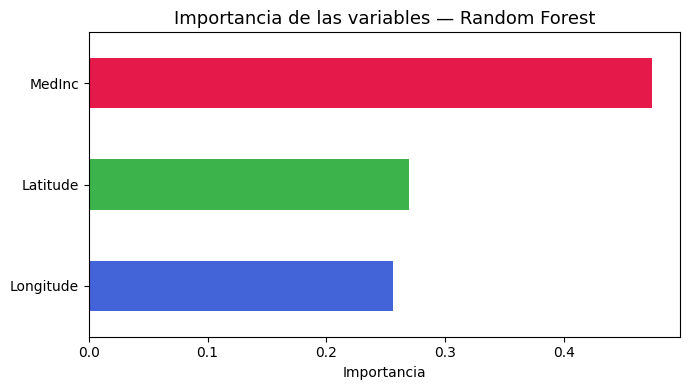

In [12]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color=['#4363d8', '#3cb44b', '#e6194b'])
ax.set_title('Importancia de las variables — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

In [13]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(rf,     'models/random_forest_model.pkl')

['models/random_forest_model.pkl']


cargamos el dataset California Housing, aplicamos K-Means para agrupar las viviendas en 6 clusters basados en ubicación e ingresos, validamos las predicciones sobre el conjunto de test visualmente, y entrenamos un Random Forest que aprendió a clasificar nuevas viviendas con alta precisión.